In [27]:
import sys
import os

# Get project root (parent of notebooks folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
print(project_root)

c:\Users\akash\Desktop\firstFolder\ml_project\ecl443\EchoEmotion


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from src.data_loader import load_dataset

In [29]:
data_path = os.path.join(project_root, "data", "ravdess")



X, y = load_dataset(data_path)

print("X shape:", X.shape)
print("y shape:", y.shape)

Found 1440 audio files


100%|██████████| 1440/1440 [01:08<00:00, 20.94it/s]


Final dataset shape: (1440, 58)
Labels shape: (1440,)
X shape: (1440, 58)
y shape: (1440,)


In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1152, 58)
Test size: (288, 58)


In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
print(np.isnan(X).sum())

0


In [ ]:
#Grid Search for SVM (better than normal svm)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 50],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.01, 0.001]
}

grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

svm_model = grid.best_estimator_

y_pred_svm = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Best Params:", grid.best_params_)
print("Improved SVM Accuracy:", svm_acc)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Params: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
Improved SVM Accuracy: 0.6631944444444444


In [35]:
#Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.6180555555555556


In [36]:
print("=== SVM Report ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== SVM Report ===
              precision    recall  f1-score   support

       angry       0.77      0.89      0.83        38
        calm       0.70      0.79      0.74        38
     disgust       0.68      0.66      0.67        38
     fearful       0.58      0.74      0.65        39
       happy       0.67      0.41      0.51        39
     neutral       0.48      0.58      0.52        19
         sad       0.75      0.55      0.64        38
   surprised       0.64      0.64      0.64        39

    accuracy                           0.66       288
   macro avg       0.66      0.66      0.65       288
weighted avg       0.67      0.66      0.66       288

=== Random Forest Report ===
              precision    recall  f1-score   support

       angry       0.71      0.71      0.71        38
        calm       0.57      0.84      0.68        38
     disgust       0.57      0.63      0.60        38
     fearful       0.71      0.62      0.66        39
       happy       0.64      0

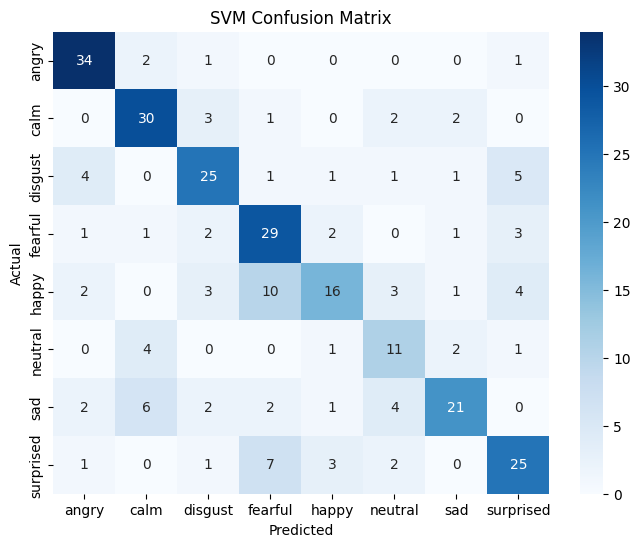

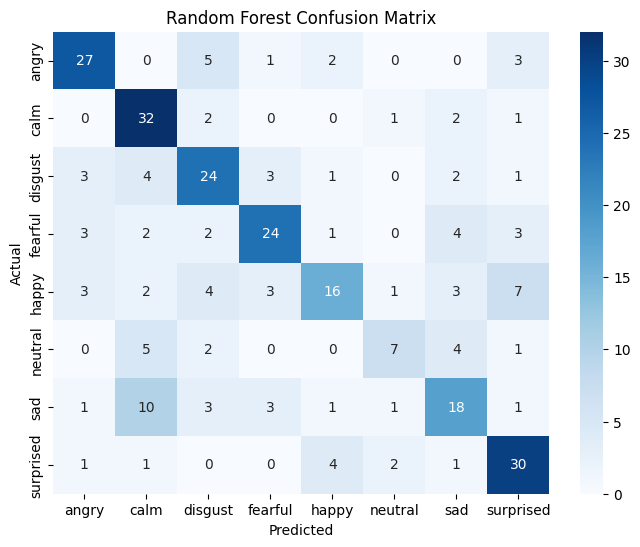

In [37]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cmap='Blues')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


plot_confusion_matrix(y_test, y_pred_svm, "SVM Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")